In [1]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Pad naar de bestanden in Google Drive
file_path_1 = "/content/drive/My Drive/Saffier/Dummydata/Input/Dummydata[jan-jul].xlsx"
file_path_2 = "/content/drive/My Drive/Saffier/Dummydata/Input/Dummydata[july-feb].xlsx"
file_path_3 = "/content/drive/My Drive/Saffier/Dummydata/Input/Dummydata[jul23-jan24].xlsx"
file_path_4 = "/content/drive/My Drive/Saffier/Dummydata/Input/Dummydata[jan23-jul23].xlsx"

# Inladen van de Excel-bestanden
df1 = pd.read_excel(file_path_1, engine="openpyxl")
df2 = pd.read_excel(file_path_2, engine="openpyxl")
df3 = pd.read_excel(file_path_3, engine="openpyxl")
df4 = pd.read_excel(file_path_4, engine="openpyxl")



Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [ ]:
df1

,Datakanaal,Omschrijving,Tijdstip (van),Tijdstip (tot),Verbruik laag,Verbruik hoog,Verbruik totaal,Meterstand
0,871689250000053880,Gas verbruik herleid berekend (7 graden method...,2024-01-17 00:00:00,2024-01-17 01:00:00,0.000,20.885,20.885,217075.979
1,871689250000053880,Gas verbruik herleid berekend (7 graden method...,2024-01-17 01:00:00,2024-01-17 02:00:00,0.000,21.288,21.288,217097.267
2,871689250000053880,Gas verbruik herleid berekend (7 graden method...,2024-01-17 02:00:00,2024-01-17 03:00:00,0.000,21.086,21.086,217118.353
3,871689250000053880,Gas verbruik herleid berekend (7 graden method...,2024-01-17 03:00:00,2024-01-17 04:00:00,0.000,21.589,21.589,217139.942
4,871689250000053880,Gas verbruik herleid berekend (7 graden method...,2024-01-17 04:00:00,2024-01-17 05:00:00,0.000,21.287,21.287,217161.229
...,...,...,...,...,...,...,...,...
26341,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,2024-07-17 19:00:00,2024-07-17 20:00:00,0.000,81.525,81.525,2280873.625
26342,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,2024-07-17 20:00:00,2024-07-17 21:00:00,0.000,74.833,74.833,2280948.458
26343,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,2024-07-17 21:00:00,2024-07-17 22:00:00,0.000,74.529,74.529,2281022.987
26344,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,2024-07-17 22:00:00,2024-07-17 23:00:00,0.000,67.533,67.533,2281090.520


In [23]:
# Merge the two dataframes
dummydata = pd.concat([df1, df2, df3, df4], ignore_index=True)

# Convert 'Tijdstip (van)' to datetime objects
dummydata['Datum & tijd'] = pd.to_datetime(dummydata['Tijdstip (van)'])

# Remove 'Tijdstip (tot)'
dummydata = dummydata.drop(columns=['Tijdstip (tot)','Tijdstip (van)'])

# Add column with month name and year
dummydata['Year'] = dummydata['Datum & tijd'].dt.year
dummydata['Month'] = dummydata['Datum & tijd'].dt.month
dummydata['Month'] = dummydata['Month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%B'))

# Remove 'Verbruik laag' and 'Verbruik hoog' columns
dummydata = dummydata.drop(columns=['Verbruik laag', 'Verbruik hoog'])

dummydata

,Datakanaal,Omschrijving,Verbruik totaal,Meterstand,Datum & tijd,Year,Month
0,871689250000053880,Gas verbruik herleid berekend (7 graden method...,20.885,217075.979,2024-01-17 00:00:00,2024,January
1,871689250000053880,Gas verbruik herleid berekend (7 graden method...,21.288,217097.267,2024-01-17 01:00:00,2024,January
2,871689250000053880,Gas verbruik herleid berekend (7 graden method...,21.086,217118.353,2024-01-17 02:00:00,2024,January
3,871689250000053880,Gas verbruik herleid berekend (7 graden method...,21.589,217139.942,2024-01-17 03:00:00,2024,January
4,871689250000053880,Gas verbruik herleid berekend (7 graden method...,21.287,217161.229,2024-01-17 04:00:00,2024,January
...,...,...,...,...,...,...,...
112459,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,37.080,806379.610,2023-07-16 19:00:00,2023,July
112460,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,31.920,806411.530,2023-07-16 20:00:00,2023,July
112461,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,32.520,806444.050,2023-07-16 21:00:00,2023,July
112462,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,26.640,806470.690,2023-07-16 22:00:00,2023,July


# 3 linden


In [25]:
import pandas as pd
import glob

# Bestandspaden
file_paths = [
    "/content/drive/My Drive/Saffier/Dummydata/Input/3linden_juli-dec2023.xlsx",
    "/content/drive/My Drive/Saffier/Dummydata/Input/3linden_juli_dec2024.xlsx",
    "/content/drive/My Drive/Saffier/Dummydata/Input/3linden_jan-juli2024.xlsx",
    "/content/drive/My Drive/Saffier/Dummydata/Input/3linden_jan-juli2023.xlsx",
    "/content/drive/My Drive/Saffier/Dummydata/Input/3linden_jan-feb2025.xlsx"
]

# Dataframes opslaan in een lijst
df_list = []

for file in file_paths:
    try:
        df = pd.read_excel(file)
        df_list.append(df)
    except Exception as e:
        print(f"Fout bij het openen van {file}: {e}")

# Gecombineerde dataset
df_3linden = pd.concat(df_list, ignore_index=True)

df_3linden




/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Fout bij het openen van /content/drive/My Drive/Saffier/Dummydata/Input/3linden_jan-juli2023.xlsx: [Errno 2] No such file or directory: '/content/drive/My Drive/Saffier/Dummydata/Input/3linden_jan-juli2023.xlsx'


/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Datakanaal,Omschrijving,Tijdstip (van),Tijdstip (tot),Verbruik laag,Verbruik hoog,Verbruik totaal,Meterstand
0,871689260011143623_BP,Bruto productie - Westhovenplein 139 CVZ S4 De...,2023-07-01 00:00:00,2023-07-01 01:00:00,0.00,0.000,0.000,NaN
1,871689260011143623_BP,Bruto productie - Westhovenplein 139 CVZ S4 De...,2023-07-01 01:00:00,2023-07-01 02:00:00,0.00,0.000,0.000,NaN
2,871689260011143623_BP,Bruto productie - Westhovenplein 139 CVZ S4 De...,2023-07-01 02:00:00,2023-07-01 03:00:00,0.00,0.000,0.000,NaN
3,871689260011143623_BP,Bruto productie - Westhovenplein 139 CVZ S4 De...,2023-07-01 03:00:00,2023-07-01 04:00:00,0.00,0.000,0.000,NaN
4,871689260011143623_BP,Bruto productie - Westhovenplein 139 CVZ S4 De...,2023-07-01 04:00:00,2023-07-01 05:00:00,0.00,0.000,0.000,NaN
...,...,...,...,...,...,...,...,...
344467,0 NVT,Watermeting Tussenmeter 180- Standen - Westhov...,2025-02-17 19:00:00,2025-02-17 20:00:00,0.00,0.141,0.141,5782.981
344468,0 NVT,Watermeting Tussenmeter 180- Standen - Westhov...,2025-02-17 20:00:00,2025-02-17 21:00:00,0.00,0.110,0.110,5783.091
344469,0 NVT,Watermeting Tussenmeter 180- Standen - Westhov...,2025-02-17 21:00:00,2025-02-17 22:00:00,0.00,0.050,0.050,5783.141
344470,0 NVT,Watermeting Tussenmeter 180- Standen - Westhov...,2025-02-17 22:00:00,2025-02-17 23:00:00,0.00,0.050,0.050,5783.191


In [26]:
#TIJD
# Convert 'Tijdstip (van)' to datetime objects
df_3linden['Datum & tijd'] = pd.to_datetime(df_3linden['Tijdstip (van)'])

# Remove 'Tijdstip (tot)' and 'Tijdstip (van)'
df_3linden = df_3linden.drop(columns=['Tijdstip (tot)', 'Tijdstip (van)'])

# Remove 'Verbruik laag' and 'Verbruik hoog' columns
df_3linden = df_3linden.drop(columns=['Verbruik laag', 'Verbruik hoog'])

df_3linden


#PANELEN
# Verwijder de kolom 'Source File' als die nog bestond
df_3linden = df_3linden.drop(columns=['Source File'], errors='ignore')

# Definieer de bruto productiekanalen
bruto_productie_kanalen = [
    'Bruto productie - Westhovenplein 139 CVZ S4 Den Haag',
    'Bruto Productie - Standen - Westhovenplein 139 BIJ S4 Den Haag',
    'Bruto productie - Westhovenplein 180 CVZ S5 Den Haag',
    'Bruto Productie 5 - Standen - Westhovenplein 180 BIJ S5 Den Haag',
    'Bruto productie - Westhovenplein 291 CVZ S3 Den Haag',
    'Bruto Productie 3 - Standen - Westhovenplein 291 BIJ S3 Den Haag'
]

# Filter de bruto productie data
df_bruto_productie = df_3linden[df_3linden['Omschrijving'].isin(bruto_productie_kanalen)].copy()

# Groepeer per datum en tel het 'Verbruik totaal' op
df_bruto_productie = df_bruto_productie.groupby(['Datum & tijd'], as_index=False).agg({'Verbruik totaal': 'sum'})

# Voeg een nieuwe omschrijving toe voor de gecombineerde bruto productie
df_bruto_productie['Omschrijving'] = 'Bruto Productie - Totaal Westhovenplein'

# Voeg de geaggregeerde bruto productie data toe aan de originele dataset
df_3linden = pd.concat([df_3linden, df_bruto_productie], ignore_index=True)

# Verwijder de originele losse bruto productie kanalen
df_3linden = df_3linden[~df_3linden['Omschrijving'].isin(bruto_productie_kanalen)]


#WATER
# Definieer de watermeter-kanalen
watermeter_kanalen = [
    'Watermeting Hoofdmeter 139- Standen - Westhovenplein 139 Den Haag',
    'Watermeting Tussenmeter 139 - Standen - Westhovenplein 139 Den Haag',
    'Watermeting Hoofdmeter 180 - Standen - Westhovenstraat 180 Den Haag',
    'Watermeting Tussenmeter 180- Standen - Westhovenstraat 180 Den Haag',
    'Watermeting Hoofdmeter 291 - Standen - Westhovenplein 291 Den Haag',
    'Watermeting Tussenmeter 291 - Standen - Westhovenplein 291 Den Haag'
]

# Filter de watermeter data
df_watermeters = df_3linden[df_3linden['Omschrijving'].isin(watermeter_kanalen)].copy()

# Groepeer per datum en tel het 'Verbruik totaal' op
df_watermeters = df_watermeters.groupby(['Datum & tijd'], as_index=False).agg({'Verbruik totaal': 'sum'})

# Voeg een nieuwe omschrijving toe voor de gecombineerde watermetingen
df_watermeters['Omschrijving'] = 'Waterverbruik - Totaal Westhovenplein'

# Voeg de geaggregeerde watermeter data toe aan de originele dataset
df_3linden = pd.concat([df_3linden, df_watermeters], ignore_index=True)

# Verwijder de originele losse watermeter kanalen
df_3linden = df_3linden[~df_3linden['Omschrijving'].isin(watermeter_kanalen)]

#ELECTRA
# Definieer de hoofdmeters LDN (CVZ + BIJ) per toren
hoofdmeters_ldn = [
    'Hoofdmeting elektriciteit LDN - Standen - Westhovenplein 139 CVZ S4 Den Haag',
    'Hoofdmeting elektriciteit LDN - Standen - Westhovenplein 139 BIJ S4 Den Haag',
    'Hoofdmeting elektriciteit LDN - Standen - Westhovenplein 180 CVZ S5 Den Haag',
    'Hoofdmeting elektriciteit LDN - Standen - Westhovenplein 180 BIJ S5 Den Haag',
    'Hoofdmeting elektriciteit LDN - Standen - Westhovenplein 291 CVZ S3 Den Haag',
    'Hoofdmeting elektriciteit LDN - Standen - Westhovenplein 291 BIJ S3 Den Haag'
]

# Filter de hoofdmeters LDN data
df_hoofdmeters_ldn = df_3linden[df_3linden['Omschrijving'].isin(hoofdmeters_ldn)].copy()

# Groepeer per datum en tel het 'Verbruik totaal' op
df_hoofdmeters_ldn = df_hoofdmeters_ldn.groupby(['Datum & tijd'], as_index=False).agg({'Verbruik totaal': 'sum'})

# Voeg een nieuwe omschrijving toe voor de gecombineerde hoofdmeters
df_hoofdmeters_ldn['Omschrijving'] = 'Hoofdmeting elektriciteit LDN - Totaal Westhovenplein'

# Voeg de geaggregeerde hoofdmeters data toe aan de originele dataset
df_3linden = pd.concat([df_3linden, df_hoofdmeters_ldn], ignore_index=True)

# Verwijder de originele losse hoofdmeters LDN
df_3linden = df_3linden[~df_3linden['Omschrijving'].isin(hoofdmeters_ldn)]

# Verwijder de werkelijk verbruik data
df_3linden = df_3linden[~df_3linden['Omschrijving'].str.contains('Werkelijk verbruik', na=False)]
df_3linden = df_3linden[~df_3linden['Omschrijving'].str.contains('ODN', na=False)]

# Add columns for year and month
df_3linden['Year'] = df_3linden['Datum & tijd'].dt.year
df_3linden['Month'] = df_3linden['Datum & tijd'].dt.month
df_3linden['Month'] = df_3linden['Month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%B'))



Voor nu hebben qe alleen de hoofdmeters bij elkaar opgeteld van CVZ + BIJ. Werklijk is weggelaten maar vgm is dat hoeveel er door de hoofdmeters is gemeten - de opgewekte energie.

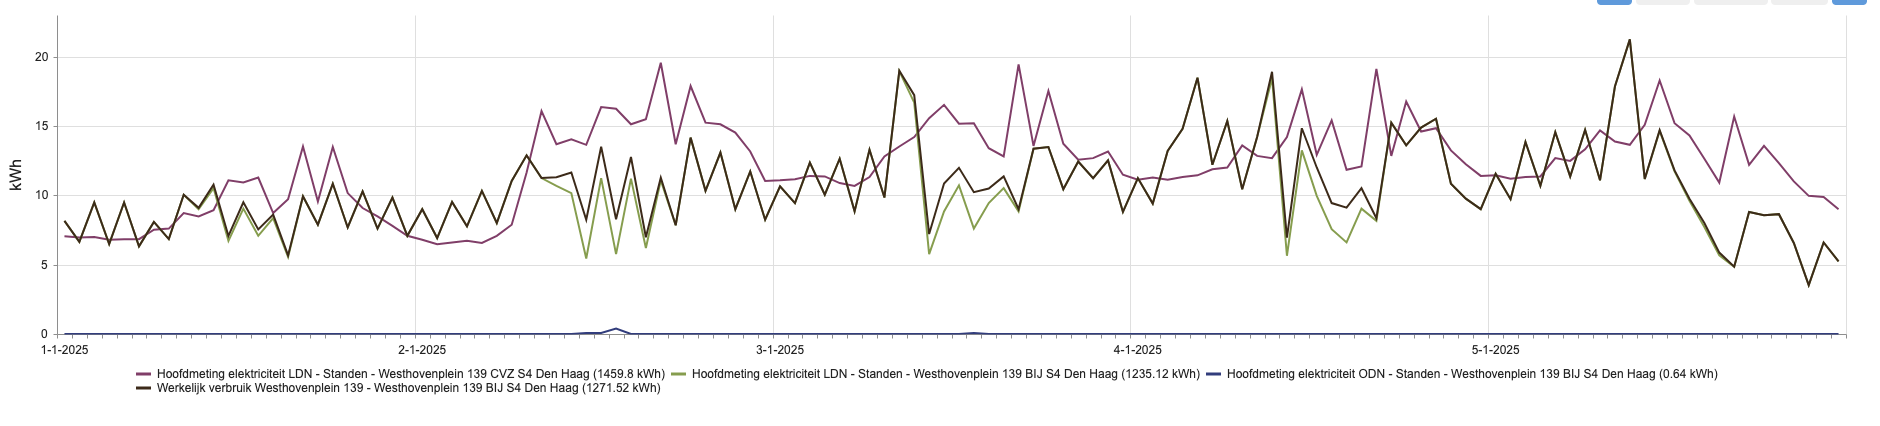

In [27]:
df_3linden

,Datakanaal,Omschrijving,Verbruik totaal,Meterstand,Datum & tijd,Year,Month
172236,NaN,Bruto Productie - Totaal Westhovenplein,0.00,NaN,2023-07-01 00:00:00,2023,July
172237,NaN,Bruto Productie - Totaal Westhovenplein,0.00,NaN,2023-07-01 01:00:00,2023,July
172238,NaN,Bruto Productie - Totaal Westhovenplein,0.00,NaN,2023-07-01 02:00:00,2023,July
172239,NaN,Bruto Productie - Totaal Westhovenplein,0.00,NaN,2023-07-01 03:00:00,2023,July
172240,NaN,Bruto Productie - Totaal Westhovenplein,0.00,NaN,2023-07-01 04:00:00,2023,July
...,...,...,...,...,...,...,...
215284,NaN,Hoofdmeting elektriciteit LDN - Totaal Westhov...,115.76,NaN,2025-02-17 19:00:00,2025,February
215285,NaN,Hoofdmeting elektriciteit LDN - Totaal Westhov...,114.94,NaN,2025-02-17 20:00:00,2025,February
215286,NaN,Hoofdmeting elektriciteit LDN - Totaal Westhov...,109.44,NaN,2025-02-17 21:00:00,2025,February
215287,NaN,Hoofdmeting elektriciteit LDN - Totaal Westhov...,109.92,NaN,2025-02-17 22:00:00,2025,February


In [28]:
#Show values rows with 126,04 for df_3linden["Verbruik totaal"]
df_3linden[df_3linden["Verbruik totaal"] == 126.04]

,Datakanaal,Omschrijving,Verbruik totaal,Meterstand,Datum & tijd,Year,Month
206251,NaN,Hoofdmeting elektriciteit LDN - Totaal Westhov...,126.04,NaN,2024-02-07 09:00:00,2024,February


In [29]:
dummydata

,Datakanaal,Omschrijving,Verbruik totaal,Meterstand,Datum & tijd,Year,Month
0,871689250000053880,Gas verbruik herleid berekend (7 graden method...,20.885,217075.979,2024-01-17 00:00:00,2024,January
1,871689250000053880,Gas verbruik herleid berekend (7 graden method...,21.288,217097.267,2024-01-17 01:00:00,2024,January
2,871689250000053880,Gas verbruik herleid berekend (7 graden method...,21.086,217118.353,2024-01-17 02:00:00,2024,January
3,871689250000053880,Gas verbruik herleid berekend (7 graden method...,21.589,217139.942,2024-01-17 03:00:00,2024,January
4,871689250000053880,Gas verbruik herleid berekend (7 graden method...,21.287,217161.229,2024-01-17 04:00:00,2024,January
...,...,...,...,...,...,...,...
112459,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,37.080,806379.610,2023-07-16 19:00:00,2023,July
112460,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,31.920,806411.530,2023-07-16 20:00:00,2023,July
112461,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,32.520,806444.050,2023-07-16 21:00:00,2023,July
112462,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,26.640,806470.690,2023-07-16 22:00:00,2023,July


In [30]:
#Merge
dummydata = pd.concat([dummydata, df_3linden], ignore_index=True)
dummydata = dummydata.sort_values(['Datum & tijd'])

# Create the new column 'Location' and initialize it with 'Unknown'
dummydata['Location'] = 'Unknown'

# Define the conditions for each location
mechropa_condition = dummydata['Omschrijving'].str.contains('Scheveningseweg 96', na=False)
royal_rustiek_condition = dummydata['Omschrijving'].str.contains('Rusthoekstraat 38', na=False)
loosduinen_condition = dummydata['Omschrijving'].str.contains('Willem III straat 36', na=False)
drielinden_condition = dummydata['Omschrijving'].str.contains('Westhovenplein', na=False)

# Set the 'Location' values based on the conditions
dummydata.loc[mechropa_condition, 'Location'] = 'Mechropa'
dummydata.loc[royal_rustiek_condition, 'Location'] = 'Royal&Rustiek'
dummydata.loc[loosduinen_condition, 'Location'] = 'Loosduinen'
dummydata.loc[drielinden_condition, 'Location'] = '3linden'

# No do the same with "Gas" and 'elektriciteit'
dummydata['Energiestroom'] = 'Unknown'
gas_condition = dummydata['Omschrijving'].str.contains('Gas', na=False)
elek_condition = dummydata['Omschrijving'].str.contains('elektriciteit', na=False)
water_condition = dummydata['Omschrijving'].str.contains('Water', na=False)
panel_condition = dummydata['Omschrijving'].str.contains('Productie', na=False)

dummydata.loc[gas_condition, 'Energiestroom'] = 'Gas'
dummydata.loc[elek_condition, 'Energiestroom'] = 'Elektriciteit'
dummydata.loc[water_condition, 'Energiestroom'] = 'Water'
dummydata.loc[panel_condition, 'Energiestroom'] = 'Zonnepanelen'

#sort on datum & tijd
dummydata = dummydata.sort_values(by='Datum & tijd')

dummydata

,Datakanaal,Omschrijving,Verbruik totaal,Meterstand,Datum & tijd,Year,Month,Location,Energiestroom
84102,871689250000054962,Gas verbruik herleid - Standen - Rusthoekstraa...,21.000,213379.000,2023-01-01 00:00:00,2023,January,Royal&Rustiek,Gas
98283,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,62.057,1266951.307,2023-01-01 00:00:00,2023,January,Loosduinen,Elektriciteit
93556,871689250000054146,Gas verbruik herleid - Standen - Willem III st...,17.000,230898.000,2023-01-01 00:00:00,2023,January,Loosduinen,Gas
107737,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,25.440,620278.690,2023-01-01 00:00:00,2023,January,Mechropa,Elektriciteit
88829,871689276000055037,Hoofdmeting elektriciteit LDN - Standen - Rust...,34.900,611501.713,2023-01-01 00:00:00,2023,January,Royal&Rustiek,Elektriciteit
...,...,...,...,...,...,...,...,...,...
126814,NaN,Bruto Productie - Totaal Westhovenplein,0.000,NaN,2025-02-17 23:00:00,2025,February,3linden,Zonnepanelen
52270,871689250000054146,Gas verbruik herleid - Standen - Willem III st...,0.000,629663.000,2025-02-17 23:00:00,2025,February,Loosduinen,Gas
57455,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,0.000,2660399.032,2025-02-17 23:00:00,2025,February,Loosduinen,Elektriciteit
36715,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,0.000,1371307.745,2025-02-17 23:00:00,2025,February,Mechropa,Elektriciteit


# Temperatuur


In [31]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Pad naar de bestanden in Google Drive
file_path = "/content/drive/My Drive/Saffier/Dummydata/Input/uurgeg_215_2021-2030.xlsx"

# Inladen van de Excel-bestanden
temp = pd.read_excel(file_path, engine="openpyxl")

# Delete the 'TD' column
temp = temp.drop(columns=[' T10N', '   TD','    T'])

# Replace 'Loaction' values with 'voorschoten' (assuming 'Location' is the correct column name)
temp['Location'] = 'Voorschoten'

# Ensure column names are correctly formatted
temp.columns = temp.columns.str.strip()

# Convert YYYYMMDD and HH to numeric
temp['YYYYMMDD'] = pd.to_numeric(temp['YYYYMMDD'], errors='coerce').dropna().astype(int).astype(str)
temp['HH'] = pd.to_numeric(temp['HH'], errors='coerce').fillna(0).astype(int)

# Fix HH=24 issue
mask = temp['HH'] == 24
temp.loc[mask, 'HH'] = 0  # Convert 24 to 00
temp.loc[mask, 'YYYYMMDD'] = (pd.to_datetime(temp.loc[mask, 'YYYYMMDD']) + pd.Timedelta(days=1)).dt.strftime('%Y%m%d')

# Create 'Datum & tijd' column
temp['Datum & tijd'] = pd.to_datetime(temp['YYYYMMDD'] + ' ' + temp['HH'].astype(str).str.zfill(2) + ':00:00')

# Extract Year and Month
temp['Year'] = temp['Datum & tijd'].dt.year
temp['Month'] = temp['Datum & tijd'].dt.strftime('%B')

# Select relevant columns
temp = temp[['Datum & tijd', 'Year', 'Month', 'Temp']]

# Delete rows with more than 1 missing value
temp = temp.dropna(thresh=len(temp.columns) - 1)

#Year as int
temp['Year'] = temp['Year'].astype(int)

temp.to_excel('/content/drive/My Drive/Saffier/Dummydata/Output/Temp[21-25].xlsx', index=False)

temp



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-31-baf68075b0f3>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Year'] = temp['Year'].astype(int)


,Datum & tijd,Year,Month,Temp
0,2021-01-01 01:00:00,2021,January,-3.1
1,2021-01-01 02:00:00,2021,January,-2.2
2,2021-01-01 03:00:00,2021,January,-1.2
3,2021-01-01 04:00:00,2021,January,-1.1
4,2021-01-01 05:00:00,2021,January,0.3
...,...,...,...,...
36235,2025-02-18 20:00:00,2025,February,-0.3
36236,2025-02-18 21:00:00,2025,February,-0.5
36237,2025-02-18 22:00:00,2025,February,-0.1
36238,2025-02-18 23:00:00,2025,February,-0.6


In [32]:
# Add to dummdata, the Temp in Temp, match based on Datum & tijd.
# Merge dummydata and temp based on 'Datum & tijd', 'Year', and 'Month'
dummydata = pd.merge(dummydata, temp, on=['Datum & tijd', 'Year', 'Month'], how='left')

# Display the updated dummydata DataFrame
dummydata



,Datakanaal,Omschrijving,Verbruik totaal,Meterstand,Datum & tijd,Year,Month,Location,Energiestroom,Temp
0,871689250000054962,Gas verbruik herleid - Standen - Rusthoekstraa...,21.000,213379.000,2023-01-01 00:00:00,2023,January,Royal&Rustiek,Gas,14.2
1,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,62.057,1266951.307,2023-01-01 00:00:00,2023,January,Loosduinen,Elektriciteit,14.2
2,871689250000054146,Gas verbruik herleid - Standen - Willem III st...,17.000,230898.000,2023-01-01 00:00:00,2023,January,Loosduinen,Gas,14.2
3,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,25.440,620278.690,2023-01-01 00:00:00,2023,January,Mechropa,Elektriciteit,14.2
4,871689276000055037,Hoofdmeting elektriciteit LDN - Standen - Rust...,34.900,611501.713,2023-01-01 00:00:00,2023,January,Royal&Rustiek,Elektriciteit,14.2
...,...,...,...,...,...,...,...,...,...,...
155512,NaN,Bruto Productie - Totaal Westhovenplein,0.000,NaN,2025-02-17 23:00:00,2025,February,3linden,Zonnepanelen,-1.9
155513,871689250000054146,Gas verbruik herleid - Standen - Willem III st...,0.000,629663.000,2025-02-17 23:00:00,2025,February,Loosduinen,Gas,-1.9
155514,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,0.000,2660399.032,2025-02-17 23:00:00,2025,February,Loosduinen,Elektriciteit,-1.9
155515,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,0.000,1371307.745,2025-02-17 23:00:00,2025,February,Mechropa,Elektriciteit,-1.9


In [34]:
#Show values rows with 126,04 for df_3linden["Verbruik totaal"]
dummydata[dummydata["Verbruik totaal"] == 126.04]


,Datakanaal,Omschrijving,Verbruik totaal,Meterstand,Datum & tijd,Year,Month,Location,Energiestroom,Temp
74031,NaN,Hoofdmeting elektriciteit LDN - Totaal Westhov...,126.04,NaN,2024-02-07 09:00:00,2024,February,3linden,Elektriciteit,5.2


In [35]:
#laat rijen zien met 07/02/2024  09:00:00
dummydata[dummydata["Datum & tijd"] == "2024-02-07 09:00:00"]

,Datakanaal,Omschrijving,Verbruik totaal,Meterstand,Datum & tijd,Year,Month,Location,Energiestroom,Temp
74026,871689250000053880,Gas verbruik herleid berekend (7 graden method...,23.295,226575.474,2024-02-07 09:00:00,2024,February,Mechropa,Gas,5.2
74027,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,92.781,2017343.644,2024-02-07 09:00:00,2024,February,Loosduinen,Elektriciteit,5.2
74028,NaN,Waterverbruik - Totaal Westhovenplein,1.269,NaN,2024-02-07 09:00:00,2024,February,3linden,Water,5.2
74029,871689250000054146,Gas verbruik herleid - Standen - Willem III st...,42.000,439893.000,2024-02-07 09:00:00,2024,February,Loosduinen,Gas,5.2
74030,871689250000054962,Gas verbruik herleid - Standen - Rusthoekstraa...,32.000,392769.000,2024-02-07 09:00:00,2024,February,Royal&Rustiek,Gas,5.2
74031,NaN,Hoofdmeting elektriciteit LDN - Totaal Westhov...,126.040,NaN,2024-02-07 09:00:00,2024,February,3linden,Elektriciteit,5.2
74032,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,51.240,1005004.425,2024-02-07 09:00:00,2024,February,Mechropa,Elektriciteit,5.2
74033,NaN,Bruto Productie - Totaal Westhovenplein,7.415,NaN,2024-02-07 09:00:00,2024,February,3linden,Zonnepanelen,5.2
74034,871689276000055037,Hoofdmeting elektriciteit LDN - Standen - Rust...,47.300,994835.475,2024-02-07 09:00:00,2024,February,Royal&Rustiek,Elektriciteit,5.2


# Tempcorrectie

In [36]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Controleer of de relevante kolommen aanwezig zijn
required_columns = ["Location", "Energiestroom", "Temp", "Verbruik totaal"]
if not all(col in dummydata.columns for col in required_columns):
    raise ValueError(f"Dataset mist vereiste kolommen: {required_columns}")

# Functie om lineaire regressie uit te voeren per locatie & energiestroom
def bereken_temp_coef(dummydata, locatie, energiestroom):
    subset = dummydata[(dummydata["Location"] == locatie) & (dummydata["Energiestroom"] == energiestroom)].dropna(subset=["Temp", "Verbruik totaal"])
    if subset.shape[0] > 1:  # Zorg dat er genoeg data is voor de regressie
        X = subset[["Temp"]].values.reshape(-1, 1)
        y = subset["Verbruik totaal"].values
        model = LinearRegression()
        model.fit(X, y)
        return model.coef_[0]  # Temperatuurcoëfficiënt
    return np.nan  # Geen data → geen coëfficiënt

# Locaties en energiestromen definiëren
locaties = ["Loosduinen", "Royal&Rustiek", "Mechropa","3linden"]
energiestromen = ["Elektriciteit", "Gas"]

# Bereken temperatuurcoëfficiënten per locatie en energiestroom
temp_coefs = {(loc, energy): bereken_temp_coef(dummydata, loc, energy) for loc in locaties for energy in energiestromen}

# Voeg de temperatuurcoëfficiënt toe aan de dataset
dummydata["Temp_Coef"] = dummydata.apply(lambda row: temp_coefs.get((row["Location"], row["Energiestroom"]), np.nan), axis=1)
dummydata

# Bereken de gemiddelde temperatuur per locatie en energiestroom
gemiddelde_temp = dummydata.groupby(["Location", "Energiestroom"])["Temp"].transform("mean")

# Bereken het gecorrigeerde verbruik
dummydata["Verbruik gecorrigeerd"] = dummydata["Verbruik totaal"] - dummydata["Temp_Coef"] * (dummydata["Temp"] - gemiddelde_temp)
dummydata

,Datakanaal,Omschrijving,Verbruik totaal,Meterstand,Datum & tijd,Year,Month,Location,Energiestroom,Temp,Temp_Coef,Verbruik gecorrigeerd
0,871689250000054962,Gas verbruik herleid - Standen - Rusthoekstraa...,21.000,213379.000,2023-01-01 00:00:00,2023,January,Royal&Rustiek,Gas,14.2,-1.283914,24.749805
1,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,62.057,1266951.307,2023-01-01 00:00:00,2023,January,Loosduinen,Elektriciteit,14.2,0.682740,60.062399
2,871689250000054146,Gas verbruik herleid - Standen - Willem III st...,17.000,230898.000,2023-01-01 00:00:00,2023,January,Loosduinen,Gas,14.2,-1.447803,21.228458
3,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,25.440,620278.690,2023-01-01 00:00:00,2023,January,Mechropa,Elektriciteit,14.2,0.479805,24.038680
4,871689276000055037,Hoofdmeting elektriciteit LDN - Standen - Rust...,34.900,611501.713,2023-01-01 00:00:00,2023,January,Royal&Rustiek,Elektriciteit,14.2,0.105020,34.593280
...,...,...,...,...,...,...,...,...,...,...,...,...
155512,NaN,Bruto Productie - Totaal Westhovenplein,0.000,NaN,2025-02-17 23:00:00,2025,February,3linden,Zonnepanelen,-1.9,NaN,NaN
155513,871689250000054146,Gas verbruik herleid - Standen - Willem III st...,0.000,629663.000,2025-02-17 23:00:00,2025,February,Loosduinen,Gas,-1.9,-1.447803,-19.081165
155514,871689276000048145,Hoofdmeting elektriciteit LDN - Standen - Will...,0.000,2660399.032,2025-02-17 23:00:00,2025,February,Loosduinen,Elektriciteit,-1.9,0.682740,8.997519
155515,871689276000050155,Hoofdmeting elektriciteit LDN - Standen - Sche...,0.000,1371307.745,2025-02-17 23:00:00,2025,February,Mechropa,Elektriciteit,-1.9,0.479805,6.323538


# DATA EXPORT

In [37]:
# Save the updated dummydata DataFrame to an Excel file
dummydata.to_excel('/content/drive/My Drive/Saffier/Dummydata/Output/Dummydata_BI.xlsx', index=False)